In [1]:
import numpy as np
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=100,n_features=2,n_informative=1,n_redundant=0
, n_classes=2,n_clusters_per_class=1,random_state=41,hypercube=False,class_sep=20)

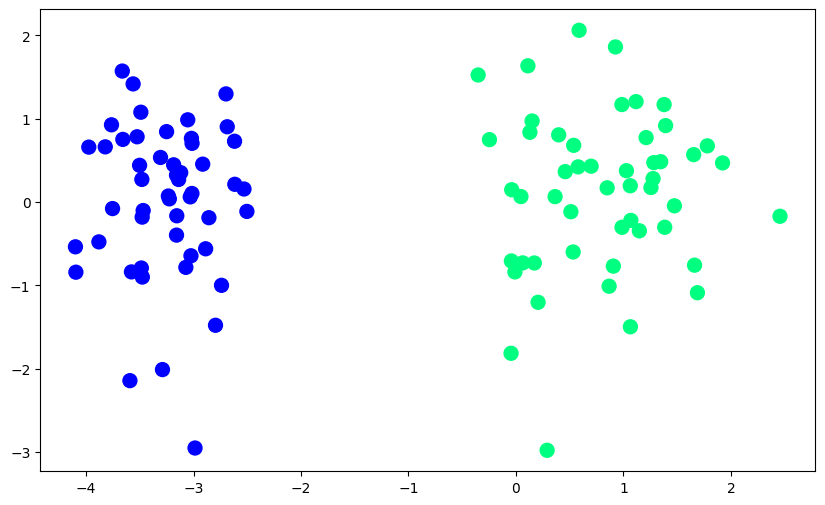

In [2]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [3]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression(penalty=None,solver='sag')
lor.fit(X,y)

c:\Users\Tarun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(penalty=None, solver='sag')

In [4]:
print(lor.coef_)
print(lor.intercept_)

[[4.81590599 0.21452926]]
[5.78970841]


In [5]:
m1 = -(lor.coef_[0][0]/lor.coef_[0][1])
b1 = -(lor.intercept_/lor.coef_[0][1])

In [6]:
x_input = np.linspace(-3,3,100)
y_input = m1*x_input+b1

In [7]:
def gd(X,y):

    X=np.insert(X,0,1,axis=1)
    weights=np.ones(X.shape[1])
    lr=0.5
    
    for i in range(2500):
        y_hat = sigmoid(np.dot(X,weights))
        weights = weights + lr*(np.dot((y-y_hat),X)/X.shape[0])
    return weights[1:],weights[0]

In [8]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [9]:
coef_,intercept_ = gd(X,y)

In [11]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [14]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input1+b